In [1]:
# redo the pathological associations
# but use linear regression and only include the SBS_D positive samples
# Mutographs

In [2]:
import pandas as pd

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)


acts_MSA = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)

si_marcos_full = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/Metadata_TMB_Signatures_SBS_ID_DBS_CN_SV_Drivers_2024AUG21.tsv',
             index_col=0)

In [4]:
acts_MSA = acts_MSA[acts_MSA.loc[:,'SBS288D']>0]

si_marcos_full = si_marcos_full.loc[acts_MSA.index]

si_marcos_full['SBS_D'] = acts_MSA.loc[:,'SBS288D'] 

In [5]:
from scipy import stats 
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm

import statsmodels.formula.api as smf

In [6]:
si_marcos_full['simple_stage'] = si_marcos_full.loc[:,'stage'].str.replace('A','').str.replace('B','').str.replace('C','')



si_marcos_full['Stage'] = si_marcos_full['simple_stage'].str.replace('IV','4').str.replace('III','3').str.replace('II','2').str.replace('I','1').str.replace('Missing','NaN').astype(float)


si_marcos_full['Grade'] = si_marcos_full.loc[:,'grade'].replace('Missing','NaN')

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86394/3815567673.py:91: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(reset_labels)


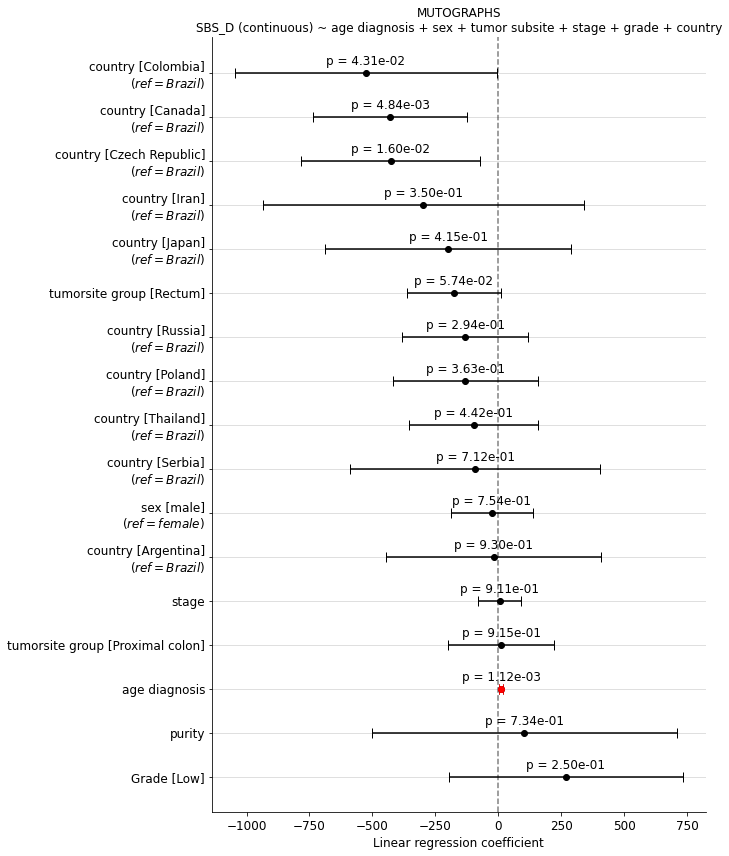

In [7]:
# linear regression with only non-zero samples

import numpy as np



model = smf.glm(formula = 'SBS_D' + " ~ age_diag + sex + tumorsite_group + purity + Stage + Grade + C(country,Treatment(reference='Brazil'))", 
            data =si_marcos_full[si_marcos_full.loc[:,'SBS_D'] > 0], )
            #family = sm.families.Binomial())

result = model.fit()
result_table = result.summary2().tables[1]

from statsmodels.stats.multitest import multipletests



result_table=result_table.drop('Intercept')
result_table = result_table.reset_index()


result_table = result_table.sort_values('Coef.',ascending=False)


fig,ax = plt.subplots(figsize=(10,12))
plt.errorbar(result_table.loc[:,'Coef.'], result_table.loc[:,'index'],
             xerr=result_table.loc[:,'Std.Err.']*2, fmt="o",capsize=5,color='black')



result_table_ = result_table[result_table.loc[:,'P>|z|'] < .05]
result_table_=result_table_[~result_table_.loc[:,'index'].str.contains('country')]
# only report the dietary variables
# result_table_ = result_table[result_table.loc[:,'index'].isin(corrected[corrected<.05].index)]
plt.errorbar(result_table_.loc[:,'Coef.'], result_table_.loc[:,'index'],
             xerr=result_table_.loc[:,'Std.Err.']*2, fmt="o",color='red',capsize=5)

plt.xlabel('coef')
plt.axvline(0,color='black',alpha=.5,linestyle='--')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


result_table.index = result_table.loc[:,'index']
for i, txt in enumerate(result_table.loc[:,'P>|z|']):
    addition = ''
    y_numeric = ax.yaxis.convert_units(result_table.loc[:,'index'][i])
    offset = 0.2 
#     if 'freq' in result_table.index[i] and corrected.loc[result_table.index[i]] < 0.05:
#         addition = ' (q-value = ' + str(round(corrected.loc[result_table.index[i]],3)) + ')'
    ax.annotate('p = ' + '{:0.2e}'.format(txt) + addition,(result_table.loc[:,'Coef.'][i],
                      y_numeric + .2),fontsize=12,ha='center',
                
              )
# for i, txt in enumerate(result_table.loc[:,'P>|z|']):
#     ax.annotate('{:0.2e}'.format(txt),(result_table.loc[:,'0.975]'][i]+50,
#                       result_table.loc[:,'index'][i]),fontsize=14)

 
plt.xlabel('Linear regression coefficient')

reset_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
#     if variable in text:
#         label = label.set_color('blue')
    text = text.replace('[T.',' [').replace('_',' ').replace(' diag',' diagnosis').replace('Stage','stage')
    if 'subsite' in text:
        text = text.replace(']',']\n$\mathit{(ref=distal\ colon)}$').lower()
    
    if 'grade' in text:
        text = text.lower().replace(']',']\n$\mathit{(ref=high)}$')
        
    if 'sex' in text:
        text = text.replace(']',']\n$\mathit{(ref=female)}$').lower()
        
 
    if 'country' in text:
        text = 'country' + text.split('))')[1].replace('\n',' ').replace(']',']\n$\mathit{(ref=Brazil)}$')
  
    
    reset_labels.append(text)    
    


ax.set_yticklabels(reset_labels)  
plt.grid(axis='y',alpha=.5)
# plt.grid(axis='y')

plt.title('MUTOGRAPHS\nSBS_D (continuous) ~ age diagnosis + sex + tumor subsite + stage + grade + country')
plt.tight_layout()

# plt.savefig('plots_for_responses/Mutographs_clinipatho_continuous.png',dpi=300)

In [8]:
# now the drivers part for 7d

In [9]:
drivers= pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/drivers/genes_with_driver_muts_MSS.tsv',index_col=0)





drivers = (drivers > 0).astype(int)





drivers['age_diag'] = si_country.loc[:,'age_diag']

drivers['tumorsite_group'] = si_marcos.loc[:,'tumorsite_group']


drivers['country'] = si_country.loc[:,'country']

drivers['sex'] = si_country.loc[:,'sex']



drivers_og= pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/drivers/genes_with_driver_muts_MSS.tsv',index_col=0)

drivers_og=drivers_og>0
drivers_og=drivers_og.astype(int)

only_consider_these = drivers_og.sum()[drivers_og.sum()>=20]


len(only_consider_these)

drivers_og['SBS_D'] = si_marcos_full.loc[:,'SBS_D']
drivers_og['SBS_D_binary'] = acts_MSA.loc[:,'SBS288D'] > 0

drivers_og['age_diag'] = si_marcos_full.loc[:,'age_diag']
drivers_og['sex'] = si_marcos_full.loc[:,'sex']
drivers_og['country'] = si_marcos_full.loc[:,'country']
drivers_og['tumorsite_group'] = si_marcos_full.loc[:,'tumorsite_group']
drivers_og['purity'] = si_marcos_full.loc[:,'purity']

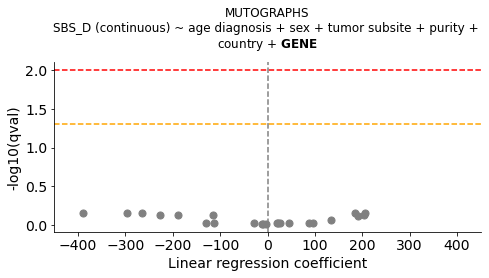

In [10]:
# so maybe the specific driver mutations? 

pvals = pd.Series(dtype=float)
coef = pd.Series(dtype=float)
for gene in list(only_consider_these.index) :

#     if gene == 'FBXW7':
#         continue

    model = smf.glm(formula = 'SBS_D' + " ~ tumorsite_group  + sex + age_diag + purity + country + " + gene, 
                data =drivers_og[drivers_og.loc[:,'SBS_D_binary'] == True], )
                #family = sm.families.Binomial())

    result = model.fit()
    # Display and interpret results
    pvals[gene] = (result.summary2().tables[1]).loc[:,'P>|z|'].loc[gene]
    coef[gene] = (result.summary2().tables[1]).loc[:,'Coef.'].loc[gene]


# val = 'SBS18_median[T.True]'

qvals = pd.Series(multipletests(pvals,method='fdr_bh')[1],index =pvals.index )
qvals.sort_values()


coef=coef#np.exp(coef)

import numpy as np 

fig,ax = plt.subplots(figsize=(7,4))
plt.scatter(coef,
        -np.log10(qvals),color='grey',s=50)

# plot just sig ones 
sigs_sigs = qvals[qvals<.05].index

plt.scatter(coef.loc[sigs_sigs],
        -np.log10(qvals.loc[sigs_sigs]),color='red',s=50)


# plt.axhline(-np.log10(.05),color='wheat',linestyle='--')
# plt.axhline(-np.log10(.01),color='coral',linestyle='--')

# plt.axvline(0,color='black',linestyle='--')


for i, txt in enumerate(coef.index):
    if qvals[i] > .05:
        continue
    ax.annotate(txt,(coef[i],
                     -np.log10(qvals)[i]),fontsize=14,color='red')

plt.xlabel('Linear regression coefficient')
plt.ylabel('-log10(qval)')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)


plt.xticks(rotation=0)

plt.axhline(-np.log10(.05),
           color='orange',linestyle='--')
plt.axhline(-np.log10(.01),
           color='red',linestyle='--')

plt.axvline(0,color='grey',linestyle='--')
plt.xlim(-450,450)

plt.title('MUTOGRAPHS\nSBS_D (continuous) ~ age diagnosis + sex + tumor subsite + purity + \ncountry + ' + r"$\bf{" + 'GENE' + "}$",fontsize=12,y=1.05)
plt.tight_layout()

# plt.savefig('plots_for_responses/Mutographs_drivers_continuous.png',dpi=300)
# plt.savefig('reviewer_plots/associations_Mutographs/volcano_driver_genes.png',
#            dpi=300)